In [1]:
from openadmet.toolkit.chemoinformatics.data_curation import CSVProcessing
import os
import pandas as pd
import numpy as np
import re

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Curating compound activity data from the Tox21 Study for model training
There are a couple of PXR datasets to start with:  
1. 'AID_1347033_datatable.csv' is the summary data from https://pubchem.ncbi.nlm.nih.gov/bioassay/1347033#section=BioAssay-Type  
2. 'AID_1346982_datatable.csv' is the assay data with replicates from https://pubchem.ncbi.nlm.nih.gov/bioassay/1346982  
3. 'AID_1346977_datatable.csv' is the counter screen assay data with replicates from https://pubchem.ncbi.nlm.nih.gov/bioassay/1346977  

Use the function `process_data` to process the raw data files, i.e. add 'CANONICAL_SMILES' and 'INCHIKEY'.

In [2]:
def process_data(input_files:list, input_path:str, output_path:str, force_process:bool=False):
    '''
    Function to process csv data tables from PubChem by adding CANONICAL_SMILES and INCHIKEY with the CSVProcessing class and outputting the resulting csv file to the "processed" folder.

    You can force reprocess all csv data tables in the "input_data" folder by setting force_process=True
    OR you can process only the csv data tables that have not already been processed, aka have a corresponding csv in the "processed" folder.
    '''
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    if force_process:
        for i in input_files:
            df = CSVProcessing.read_csv(os.path.join(input_path, i))
            processor = CSVProcessing()
            data = processor.standardize_smiles_and_convert(data=df)
            data.astype(str).to_parquet(os.path.join(output_path, f"processed_{i[:-4]}.parquet"), index=False)
    
    else: # process only input files that have not already been processed
        processed_files = os.listdir(output_path)

        for i in input_files:
            if not any(i[:-3] in f[:-7] for f in processed_files):
                df = CSVProcessing.read_csv(os.path.join(input_path, i))
                processor = CSVProcessing()
                data = processor.standardize_smiles_and_convert(data=df)
                data.astype(str).to_parquet(os.path.join(output_path, f"processed_{i[:-4]}.parquet"), index=False)


## Select the protein you'd like to to process data for
1. Create a subfolder within `/input_data` with the name of your protein of interest and upload the relevant `csv` files  
2. Enter below for the `protein` variable the name of your folder as a string; after data processing, the processed files will be `/processed/{protein}`  
3. Also enter the type of activity read out for downstream data cleaning.

In [3]:
protein = "PXR"
ac50 = "EC50"

In [4]:
root = os.getcwd()
input_folder = 'input_data'
output_folder = 'processed'
input_path = os.path.join(root, input_folder, protein)
output_path = os.path.join(root, output_folder, protein)

input_files = [file for file in os.listdir(input_path) if '.csv' in file]

process_data(input_files=input_files, input_path=input_path, output_path=output_path)

## Now ingest the processed data files for cleaning
If `/processed` folder includes files from multiple proteins, will need to add some logic to get only the data files for, e.g. PXR

In [5]:
processed_files = [x for x in os.listdir(output_path) if '33' in x]
processed_files

['processed_AID_1347033_datatable.parquet']

In [6]:
def make_data_dict(files, path):
    data = {}

    for i in files:
        df = pd.read_parquet(os.path.join(path, i))

        #assign human friendly names to each dataframe
        if any("Replicate" in col for col in df.columns):
            # check if 'cytotoxic' is anywhere in the dataframe
            # this will be the counter screen data
            substring="cytotoxic"
            substring_found = df.astype(str).apply(lambda x: x.str.contains(substring, case=False, na=False)).any().any()

            if substring_found:
                key = "counter"
            else:
                key = "rep"
            data[key] = df
        else:
            data["summary"] = df
    
    return data

In [7]:
data = make_data_dict(files=processed_files, path=output_path)

### Clean up the replicate data and merge
1. Get the means and standard deviations for all numeric replicate columns  
2. Calculate pAC50 from potency  
3. Drop columns that have all `NaN`  
4. Select only the newly calculated `mean` and `std` columns AND the `OPENADMET_CANONICAL_SMILES` and `INCHIKEY` columns  
5. Merge the screen replicate and counter screen replicate data

In [8]:
for key in data:

    if key == 'rep':
        # Calculate pAC50 from Potency (uM)
        # cast float to appropriate data types
        potency_cols = [col for col in data[key].columns if re.match(r"Potency-Replicate_\d+$", col)]
        for i in potency_cols:
            data[key][f"pAC50{i[7:]}"] = -np.log10(data[key][i].astype(float)*1e-6)

        # Get means and stdevs for pAC50, HillSlopes, and R2 columns
        strings = ['pAC50', 'Fit_HillSlope', 'Fit_R2']
        for i in strings:
            cols = [col for col in data[key].columns if re.match(fr"{i}-Replicate_\d+$", col)]
            data[key][f"{i.lower()}_mean"] = data[key][cols].astype(float).mean(axis=1)
            data[key][f"{i.lower()}_std"] = data[key][cols].astype(float).std(axis=1)

    
    elif key == 'counter':
        # Get counter screen viable data from first 3 phenotype-replicate columns
        data[key]['counter_phenotype'] = data[key][['Phenotype-Replicate_1', 'Phenotype-Replicate_2', 'Phenotype-Replicate_3']].mode(axis=1)[0]

    print(len(data[key]))
        

9478


In [9]:
summary_df = data['summary']
summary_df

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,Activity Summary,Agonist Activity,Agonist Potency (uM),Agonist Efficacy (%),Viability Activity,Viability Potency (uM),Viability Efficacy (%),Sample Source,OPENADMET_CANONICAL_SMILES,INCHIKEY
0,1,170465705.0,10219.0,CC[C@H]1CN2CCC3=CC(=C(C=C3[C@@H]2C[C@@H]1C[C@@...,Active,100.0,nan,nan,active agonist,active agonist,0.03349146,211.4194337,active antagonist,0.037578,-58.1492,Enzo,CC[C@H]1CN2CCC3=CC(OC)=C(OC)C=C3[C@@H]2C[C@@H]...,AUVVAXYIELKVAI-CKBKHPSWSA-N
1,2,170465704.0,6708701.0,C[C@]12C3CCC([C@]1(C(=O)OC2=O)C)O3,Active,99.0,nan,nan,active agonist,active agonist,1.01921876,362.3484966,active antagonist,0.237101,-73.1631,Enzo,C[C@@]12C(=O)OC(=O)[C@]1(C)C1CCC2O1,DHZBEENLJMYSHQ-OBDNUKKESA-N
2,3,144214002.0,7594.0,C1=CC=C(C=C1)NC(=NC2=CC=CC=C2)N,Active,93.0,nan,nan,active agonist,active agonist,4.86743404,489.9294473,active antagonist,5.6492,-54.6079,SIGMA,N=C(NC1=CC=CC=C1)NC1=CC=CC=C1,OWRCNXZUPFZXOS-UHFFFAOYSA-N
3,4,144206912.0,156414.0,C=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C...,Active,91.0,nan,nan,active agonist,active agonist,11.00527102,655.906322,active antagonist,2.87255,-44.3797,Selleck,C=CC(=O)NC1=CC2=C(NC3=CC=C(F)C(Cl)=C3)N=CN=C2C...,OMZCMEYTWSXEPZ-UHFFFAOYSA-N
4,5,144213201.0,5280443.0,C1=CC(=CC=C1C2=CC(=O)C3=C(C=C(C=C3O2)O)O)O,Active,90.0,nan,nan,active agonist,active agonist,22.53850342,949.4401877,active antagonist,27.5955,-72.5478,LightBiologicals,O=C1C=C(C2=CC=C(O)C=C2)OC2=CC(O)=CC(O)=C12,KZNIFHPLKGYRTM-UHFFFAOYSA-N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9473,9663,251919825.0,1127.0,C1CCSC1,Inactive,0.0,nan,nan,inactive,inactive,nan,0,inactive,nan,0,TCI America,C1CCSC1,RAOIDOHSFRTOEL-UHFFFAOYSA-N
9474,9664,251919641.0,104856.0,CN(CCCC(C1=CN=CC=C1)O)N=O,Inactive,0.0,nan,nan,inactive,inactive,nan,0,inactive,nan,0,"Toronto Research Chemicals, Inc.",CN(CCCC(O)C1=CC=CN=C1)N=O,OGRXKBUCZFFSTL-UHFFFAOYSA-N
9475,9665,251919683.0,104556.0,C1N(CN(CN1CCO)CCO)CCO,Inactive,0.0,nan,nan,inactive,inactive,nan,0,inactive,nan,0,"Toronto Research Chemicals, Inc.",OCCN1CN(CCO)CN(CCO)C1,HUHGPYXAVBJSJV-UHFFFAOYSA-N
9476,9666,251919642.0,47289.0,CN(CCCC(=O)C1=CN=CC=C1)N=O,Inactive,0.0,nan,nan,inactive,inactive,nan,0,inactive,nan,0,"Toronto Research Chemicals, Inc.",CN(CCCC(=O)C1=CC=CN=C1)N=O,FLAQQSHRLBFIEZ-UHFFFAOYSA-N


In [10]:
summary_df.columns

Index(['PUBCHEM_RESULT_TAG', 'PUBCHEM_SID', 'PUBCHEM_CID',
       'PUBCHEM_EXT_DATASOURCE_SMILES', 'PUBCHEM_ACTIVITY_OUTCOME',
       'PUBCHEM_ACTIVITY_SCORE', 'PUBCHEM_ACTIVITY_URL',
       'PUBCHEM_ASSAYDATA_COMMENT', 'Activity Summary', 'Agonist Activity',
       'Agonist Potency (uM)', 'Agonist Efficacy (%)', 'Viability Activity',
       'Viability Potency (uM)', 'Viability Efficacy (%)', 'Sample Source',
       'OPENADMET_CANONICAL_SMILES', 'INCHIKEY'],
      dtype='object')

In [11]:
summary_df["Agonist Potency (uM)"] = pd.to_numeric(summary_df["Agonist Potency (uM)"], errors="coerce")

summary_df["Agonist Potency (uM)"].isna().value_counts()

Agonist Potency (uM)
True     6546
False    2932
Name: count, dtype: int64

In [12]:
len(summary_df["INCHIKEY"].unique())

7196

In [13]:
# summary_df["Agonist Potency (uM)"] = pd.to_numeric(summary_df["Agonist Potency (uM)"], errors="coerce")

agg_data = summary_df.groupby("INCHIKEY", as_index=False).agg({
    "Agonist Potency (uM)": "mean",
    "OPENADMET_CANONICAL_SMILES": "first"
})
agg_data

,INCHIKEY,Agonist Potency (uM),OPENADMET_CANONICAL_SMILES
0,AADCDMQTJNYOSS-LBPRGKRZSA-N,18.833632,CCC1=CC(Cl)=C(OC)C(C(=O)NC[C@@H]2CCCN2CC)=C1O
1,AADVZSXPNRLYLV-GKMXPDSGSA-N,NaN,O=C(O)[C@@H]1[C@H]2C[C@H]3C4=C(CCN3C[C@@H]2CC[...
2,AAEVYOVXGOFMJO-UHFFFAOYSA-N,28.625186,CSC1=NC(NC(C)C)=NC(NC(C)C)=N1
3,AAFXQFIGKBLKMC-KQQUZDAGSA-N,NaN,O=C(O)/C=C/C1=CC=C(/C=C/C(=O)O)C=C1
4,AAIBYZBZXNWTPP-UHFFFAOYSA-N,NaN,OC1CCCCC1C1=CC=CC=C1
...,...,...,...
7191,ZZXUZKXVROWEIF-UHFFFAOYSA-N,NaN,CCC1COC(=O)O1
7192,ZZYASVWWDLJXIM-UHFFFAOYSA-N,24.637733,CC(C)(C)C1=CC(=O)C(C(C)(C)C)=CC1=O
7193,ZZYSLNWGKKDOML-UHFFFAOYSA-N,22.538503,CCC1=NN(C)C(C(=O)NCC2=CC=C(C(C)(C)C)C=C2)=C1Cl
7194,ZZYXNRREDYWPLN-UHFFFAOYSA-N,54.482673,NC1=CC=CN=C1N


In [14]:
final_output = 'final'
final_output_path = os.path.join(root, final_output)
agg_data.to_parquet(os.path.join(final_output_path, f"potencyNaN_{protein}_tox21_data.parquet"), index=False)

/Users/cynthiaxu/miniconda3/envs/openadmet/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Agonist Potency (uM)', ylabel='Count'>

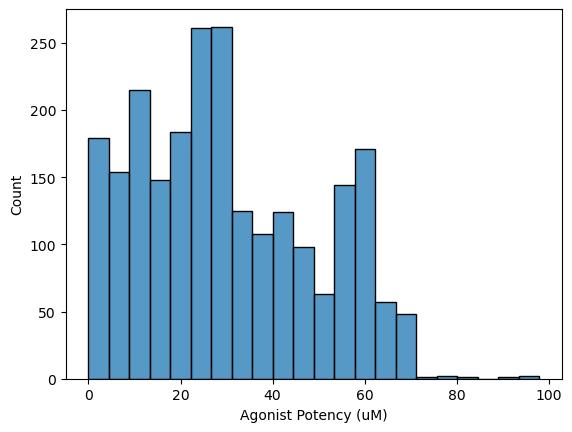

In [15]:
import seaborn as sns

sns.histplot(data=agg_data, x="Agonist Potency (uM)")

In [16]:
agg_data = agg_data.loc[~agg_data["Agonist Potency (uM)"].isna()]
agg_data

,INCHIKEY,Agonist Potency (uM),OPENADMET_CANONICAL_SMILES
0,AADCDMQTJNYOSS-LBPRGKRZSA-N,18.833632,CCC1=CC(Cl)=C(OC)C(C(=O)NC[C@@H]2CCCN2CC)=C1O
2,AAEVYOVXGOFMJO-UHFFFAOYSA-N,28.625186,CSC1=NC(NC(C)C)=NC(NC(C)C)=N1
5,AAKJLRGGTJKAMG-UHFFFAOYSA-N,10.192188,C#CC1=CC=CC(NC2=NC=NC3=CC(OCCOC)=C(OCCOC)C=C23...
7,AAOVKJBEBIDNHE-UHFFFAOYSA-N,34.287487,CN1C(=O)CN=C(C2=CC=CC=C2)C2=CC(Cl)=CC=C21
8,AAPVQEMYVNZIOO-UHFFFAOYSA-N,21.689943,O=S1(=O)OCC2C(CO1)C1(Cl)C(Cl)=C(Cl)C2(Cl)C1(Cl)Cl
...,...,...,...
7184,ZZMVLMVFYMGSMY-UHFFFAOYSA-N,9.893782,CC(C)CC(C)NC1=CC=C(NC2=CC=CC=C2)C=C1
7189,ZZVUWRFHKOJYTH-UHFFFAOYSA-N,47.516108,CN(C)CCOC(C1=CC=CC=C1)C1=CC=CC=C1
7192,ZZYASVWWDLJXIM-UHFFFAOYSA-N,24.637733,CC(C)(C)C1=CC(=O)C(C(C)(C)C)=CC1=O
7193,ZZYSLNWGKKDOML-UHFFFAOYSA-N,22.538503,CCC1=NN(C)C(C(=O)NCC2=CC=C(C(C)(C)C)C=C2)=C1Cl


In [17]:


agg_data.to_parquet(os.path.join(final_output_path, f"potency_{protein}_tox21_data.parquet"), index=False)